In [ ]:
import sys
from pathlib import Path
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

sys.path.append(str(Path.cwd().parent))
from src.classification import gradientDescent, losses, boundaries, predict


# Load Data

train_data = pd.read_csv("../data/student_train.csv",sep="\t")
test_data = pd.read_csv("../data/student_test.csv",sep="\t")

X_train = train_data[["Exam1_score", "Exam2_score"]].values
y_train = train_data["Admitted"].values

X_test = test_data[["Exam1_score", "Exam2_score"]].values
y_test = test_data["Admitted"].values

# Convert labels {0,1} → {-1,+1}
y_train = np.where(y_train == 1, 1, -1)
y_test = np.where(y_test == 1, 1, -1)

pairs=list(zip(X_train,y_train))

w=gradientDescent(X_train,y_train)

# Loss curve

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Hinge Loss")
plt.title("Scratch Model Training Loss")
plt.show()

plt.figure()

# Define x values for plotting
x_vals = np.linspace(X_train[:,0].min() - 5, X_train[:,0].max() + 5, 100)

for i in range(0,len(boundaries),20):
    w_temp = boundaries[i]
    if w_temp[1] != 0:
        y_vals = -(w_temp[0]*x_vals)/w_temp[1]
        plt.plot(x_vals,y_vals, label=f'epoch {i}')

# Plot training points
for x,y in zip(X_train,y_train):
    if y == 1:
        plt.scatter(x[0],x[1],marker='o', color='blue')
    else:
        plt.scatter(x[0],x[1],marker='x', color='red')

plt.xlabel("Exam1")
plt.ylabel("Exam2")
plt.title("Decision Boundary Evolution")
plt.legend()
plt.show()


# Test Accuracy
correct = 0
for x,y in zip(X_train,y_train):
    pred = predict(x,w)
    if pred == y:
        correct += 1

accuracy = correct / len(pairs)
print("Test Accuracy:", accuracy)

ModuleNotFoundError: No module named 'ML_Algorithms_From_Scratch'

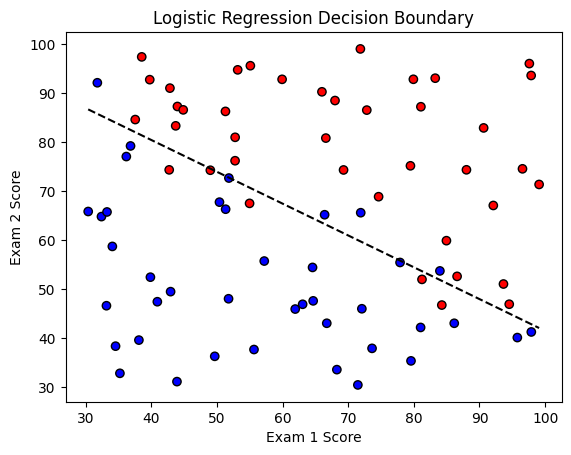

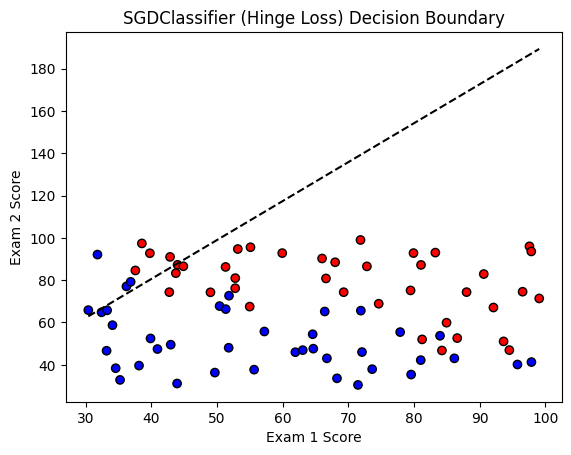

Logistic Regression - Train Accuracy: 0.8875
Logistic Regression - Test Accuracy: 0.95
SGDClassifier (Hinge Loss) - Train Accuracy: 0.5
SGDClassifier (Hinge Loss) - Test Accuracy: 0.55


In [ ]:
#task 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, SGDClassifier

# Load Data
train_data = pd.read_csv("../data/student_train.csv", sep="\t")
test_data = pd.read_csv("../data/student_test.csv", sep="\t")

X_train = train_data[["Exam1_score", "Exam2_score"]].values
y_train = train_data["Admitted"].values

X_test = test_data[["Exam1_score", "Exam2_score"]].values
y_test = test_data["Admitted"].values

# Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Train SGDClassifier (hinge loss)
sgd = SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3)
sgd.fit(X_train, y_train)

def plot_boundary(model, X, y, title):
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    coef = model.coef_[0]
    intercept = model.intercept_[0]
    if abs(coef[1]) > 1e-6:
        y_vals = -(coef[0]*x_vals + intercept)/coef[1]
        plt.plot(x_vals, y_vals, 'k--')
    else:
        x_val = -intercept/coef[0]
        plt.axvline(x=x_val, color='k', linestyle='--')
    plt.title(title)
    plt.xlabel("Exam 1 Score")
    plt.ylabel("Exam 2 Score")
    plt.show()

# Visualizations
plot_boundary(log_reg, X_train, y_train, "Logistic Regression Decision Boundary")
plot_boundary(sgd, X_train, y_train, "SGDClassifier (Hinge Loss) Decision Boundary")


# Accuracy Comparison
print("Logistic Regression - Train Accuracy:", log_reg.score(X_train, y_train))
print("Logistic Regression - Test Accuracy:", log_reg.score(X_test, y_test))

print("SGDClassifier (Hinge Loss) - Train Accuracy:", sgd.score(X_train, y_train))
print("SGDClassifier (Hinge Loss) - Test Accuracy:", sgd.score(X_test, y_test))

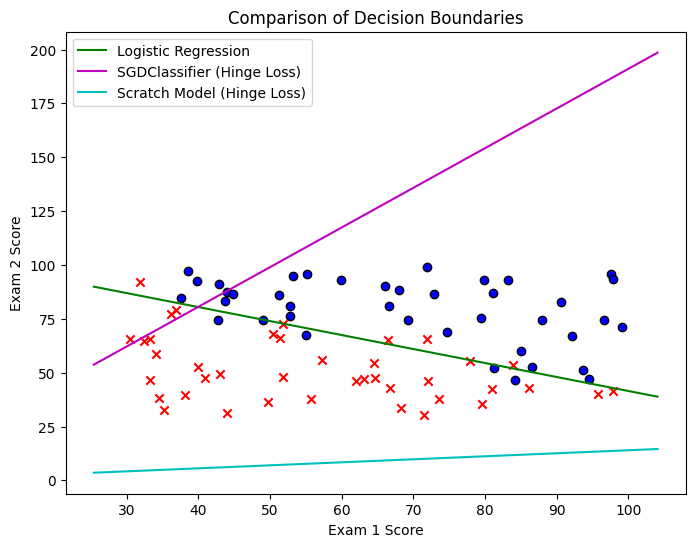

In [ ]:
# Overlay decision boundaries for Logistic Regression, SGDClassifier, and Scratch Model
plt.figure(figsize=(8,6))

# Plot training points
for x, y in zip(X_train, y_train):
    if y == 1:
        plt.scatter(x[0], x[1], marker='o', color='blue', edgecolors='k')
    else:
        plt.scatter(x[0], x[1], marker='x', color='red')

x_vals = np.linspace(X_train[:,0].min()-5, X_train[:,0].max()+5, 200)

# Logistic Regression boundary
coef = log_reg.coef_[0]
intercept = log_reg.intercept_[0]
y_vals = -(coef[0]*x_vals + intercept)/coef[1]
plt.plot(x_vals, y_vals, 'g-', label="Logistic Regression")

# SGDClassifier boundary
coef = sgd.coef_[0]
intercept = sgd.intercept_[0]
y_vals = -(coef[0]*x_vals + intercept)/coef[1]
plt.plot(x_vals, y_vals, 'm-', label="SGDClassifier (Hinge Loss)")

# Scratch model boundary (final weights w)
if w[1] != 0:
    y_vals = -(w[0]*x_vals)/w[1]
    plt.plot(x_vals, y_vals, 'c-', label="Scratch Model (Hinge Loss)")

plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("Comparison of Decision Boundaries")
plt.legend()
plt.show()